---
title: The Single Sinusoidal Model
---

We now look at another example for nonlinear regression. The following dataset is downloaded from https://www.sidc.be/SILSO/datafiles (silso stands for sunspot index and long term solar observations). Data description can be found here: https://www.sidc.be/SILSO/infosnytot. There are five columns:

1. Column 1 is the year (2020.5 refers to the year 2020 for example)
2. Column 2 is the yearly mean total sunspot number (this is obtained by taking a simple arithmetic mean of the daily sunspot number over all the days for that year)
3. Column 3 is the yearly mean standard deviation of the input sunspot numbers from individual stations (-1 indicates missing value)
4. Column 4 is the number of observations used to compute the yearly mean sunspot number (-1 indicates a missing value)
5. Column 5 is a definitive/provisional marker (1 indicates that the data point is definitive, and 0 indicates that it is still provisional)

We shall work with the data in column 2 (yearly mean total sunspot number). 

In [239]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [240]:
#annual sunspots dataset:
sunspots = pd.read_csv('SN_y_tot_V2.0_17Sept2026.csv', header = None, sep = ';')
print(sunspots.head())
sunspots.columns = ['year', 'sunspotsmean', 'sunspotssd', 'sunspotsnobs', 'isdefinitive']
print(sunspots.head(10))
print(sunspots.tail(10))

        0     1    2  3  4
0  1700.5   8.3 -1.0 -1  1
1  1701.5  18.3 -1.0 -1  1
2  1702.5  26.7 -1.0 -1  1
3  1703.5  38.3 -1.0 -1  1
4  1704.5  60.0 -1.0 -1  1
     year  sunspotsmean  sunspotssd  sunspotsnobs  isdefinitive
0  1700.5           8.3        -1.0            -1             1
1  1701.5          18.3        -1.0            -1             1
2  1702.5          26.7        -1.0            -1             1
3  1703.5          38.3        -1.0            -1             1
4  1704.5          60.0        -1.0            -1             1
5  1705.5          96.7        -1.0            -1             1
6  1706.5          48.3        -1.0            -1             1
7  1707.5          33.3        -1.0            -1             1
8  1708.5          16.7        -1.0            -1             1
9  1709.5          13.3        -1.0            -1             1
       year  sunspotsmean  sunspotssd  sunspotsnobs  isdefinitive
316  2016.5          39.8         3.9          9940             1
31

0     8.3
1    18.3
2    26.7
3    38.3
4    60.0
Name: sunspotsmean, dtype: float64


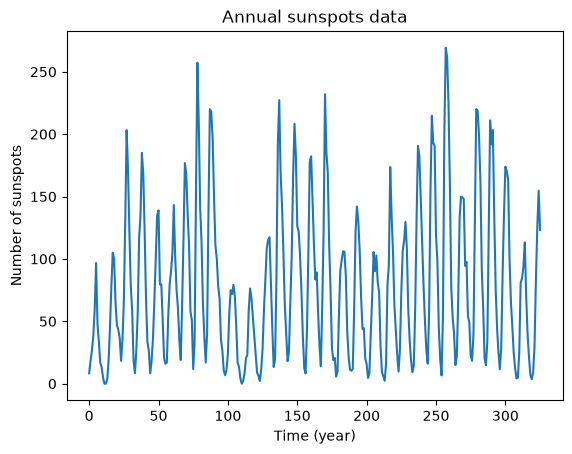

In [241]:
y = sunspots['sunspotsmean']
print(y.head())
plt.plot(y)
plt.xlabel('Time (year)')
plt.ylabel('Number of sunspots')
plt.title('Annual sunspots data')
plt.show()

We will fit the sinusoidal model: 
\begin{equation*}
  y_t = \beta_0 + \beta_1 \cos(2 \pi f t) + \beta_2 \sin(2 \pi f t) + \epsilon_t
\end{equation*}
with $\epsilon_t$ being i.i.d $N(0, \sigma^2)$. When $f$ is known, this is a linear regression model. We can fit this model to the data and see how good the fit is while varying $f$. This will give us an idea of which frequencies give good fits to the data. Later we shall consider $f$ as an unknown parameter and discuss estimation and inference for $f$. 

                            OLS Regression Results                            
Dep. Variable:           sunspotsmean   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     70.85
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           3.08e-26
Time:                        19:27:55   Log-Likelihood:                -1747.8
No. Observations:                 326   AIC:                             3502.
Df Residuals:                     323   BIC:                             3513.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         78.8672      2.868     27.496      0.0

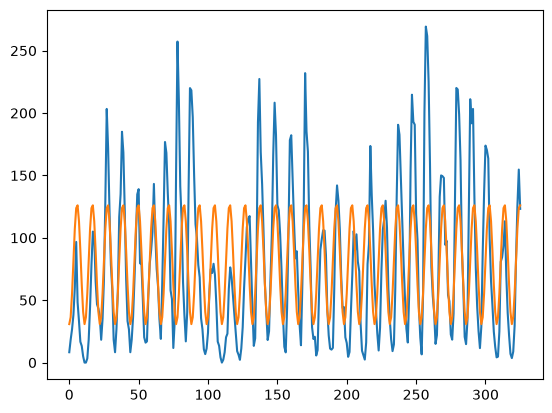

In [249]:
#Let us try some frequencies to get  intuition:
n = len(y)
x = np.arange(1, n+1)
#f = 1/10
f = 1/11 #wikipedia article on sunspots states that the sunspots periodicity is 11
#f = 1/4
#f = 1/15
sinvals = np.sin(2 * np.pi * f * x)
cosvals = np.cos(2 * np.pi * f * x)
X = np.column_stack([np.ones(n), sinvals, cosvals])
md = sm.OLS(y, X).fit()
print(md.summary())

plt.plot(y)
plt.plot(md.fittedvalues)
plt.show()


As before, we use RSS to calculate goodness of fit. We can vary over the values of $f$ and find the $f$ for which RSS is minimized. 

In [250]:
def rss(f):
    x = np.arange(1, n+1)
    xcos = np.cos(2 * np.pi * f * x)
    xsin = np.sin(2 * np.pi * f * x)
    X = np.column_stack([np.ones(n), xcos, xsin])
    md = sm.OLS(y, X).fit()
    rss = np.sum(md.resid ** 2)
    return rss

In [251]:
print(rss(1/15))
print(rss(1/4))
print(rss(1/11))
print(rss(1/10))

1237547.3570884266
1245855.676842052
866137.4198804202
1084321.0991144143


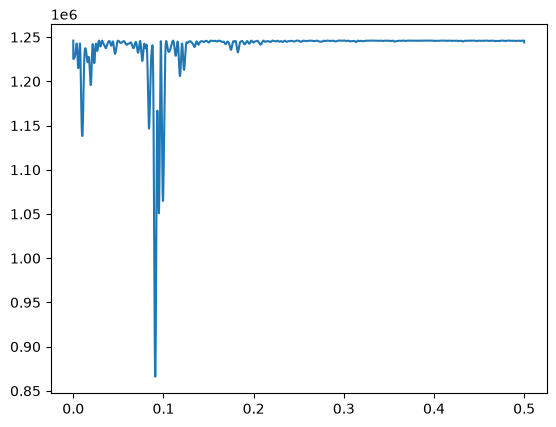

In [254]:
num_f_vals = 20000 #this is the number of different values of f we will try
allfvals = np.linspace(0, 0.5, num_f_vals)
rssvals = np.array([rss(f) for f in allfvals])
plt.plot(allfvals, rssvals)
plt.show()

In [255]:
fhat = allfvals[np.argmin(rssvals)]
print(fhat)
print(1/fhat) #this is the estimated periodicity in years

0.09090454522726137
11.000550055005501


To estimate $\beta_0, \beta_1, \beta_2$ and $\sigma$, we simply run linear regression with $f = \hat{f}$:

In [256]:
f = fhat
x = np.arange(1, n+1)
xcos = np.cos(2 * np.pi * f * x)
xsin = np.sin(2 * np.pi * f * x)
X = np.column_stack([np.ones(n), xcos, xsin])
md = sm.OLS(y, X).fit()
print(md.summary())
sighat = np.sqrt(np.sum(md.resid ** 2) / (n - 3))
print(md.params, sighat)

                            OLS Regression Results                            
Dep. Variable:           sunspotsmean   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     70.85
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           3.07e-26
Time:                        19:32:19   Log-Likelihood:                -1747.8
No. Observations:                 326   AIC:                             3502.
Df Residuals:                     323   BIC:                             3513.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         78.8668      2.868     27.496      0.0

Let us now do uncertainty quantification for $f$. We use the posterior formula: 
\begin{align*}
  \text{posterior}(f) \propto I\{0 < f < 1/2 \} |X_f^T X_f|^{-1/2} \left(\frac{1}{RSS(f)} \right)^{(n-p)/2}
\end{align*}

In [257]:
def logpost(f):
    x = np.arange(1, n+1)
    xcos = np.cos(2 * np.pi * f * x)
    xsin = np.sin(2 * np.pi * f * x)
    X = np.column_stack([np.ones(n), xcos, xsin])
    p = X.shape[1]
    md = sm.OLS(y, X).fit()
    rss = np.sum(md.resid ** 2)
    sgn, log_det = np.linalg.slogdet(np.dot(X.T, X)) #sgn gives the sign of the determinant (in our case, this should 1)
    #log_det gives the logarithm of the absolute value of the determinant
    logval = ((p-n)/2) * np.log(rss) - (0.5)*log_det
    return logval

The main role in this calculation is played by the $RSS(f)$ term. The other term $|X_f^T X_f|^{-1/2}$ generally does not vary much with $f$. This is demonstrated below. 

In [258]:
def logpost_nodet(f): #here we are calculating the log posterior without the determinant term (just to see how much difference it makes)
    x = np.arange(1, n+1)
    xcos = np.cos(2 * np.pi * f * x)
    xsin = np.sin(2 * np.pi * f * x)
    X = np.column_stack([np.ones(n), xcos, xsin])
    p = X.shape[1]
    md = sm.OLS(y, X).fit()
    rss = np.sum(md.resid ** 2)
    sgn, log_det = np.linalg.slogdet(np.dot(X.T, X)) #sgn gives the sign of the determinant (in our case, this should 1)
    #log_det gives the logarithm of the absolute value of the determinant
    logval = ((p-n)/2) * np.log(rss) #- (0.5)*log_det #we drop the determinant term
    return logval

While evaluating the log-posterior, we remove values of $f$ that are too close to 0 or 0.5 (because otherwise the determinant term $|X_f^T X_f|$ might be too close to zero). 

In [259]:
allfvals_modified = allfvals[10:-10]
logpostvals = np.array([logpost(f) for f in allfvals_modified])
logpostvals_nodet = np.array([logpost_nodet(f) for f in allfvals_modified]) 

Below we plot the log-posterior with the determinant term (which is the correct formula), and without the determinant term. 

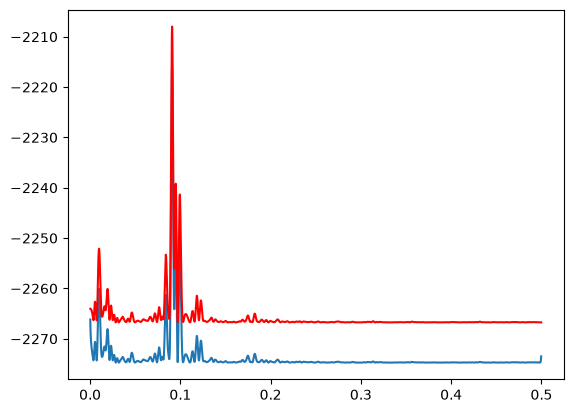

In [260]:
plt.plot(allfvals_modified, logpostvals)
plt.plot(allfvals_modified, logpostvals_nodet, color = 'red')
plt.show()


The two curves above look largely parallel (except for frequencies $f$ which are close to the endpoints). This suggests that the determinant has minimal impact on the posterior. Below we plot their difference.

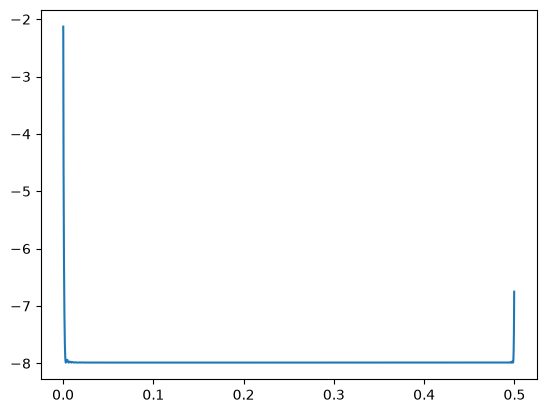

In [261]:
plt.plot(allfvals_modified, logpostvals - logpostvals_nodet)
plt.show()


Again the determinant term is only having an effect near the endpoints. This shows that the main term in the posterior is the term involving the RSS. 

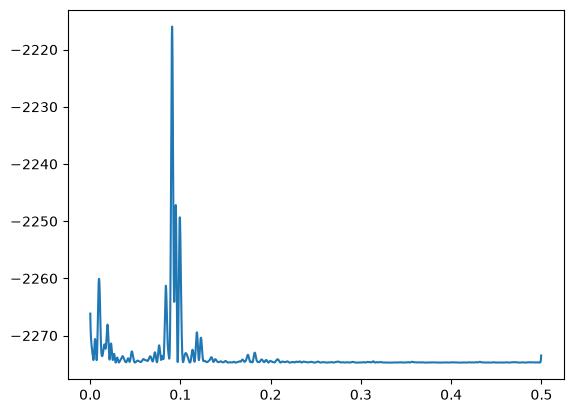

In [262]:
allfvals_modified = allfvals[10:-10]
logpostvals = np.array([logpost(f) for f in allfvals_modified])
postvals = np.exp(logpostvals - np.max(logpostvals))
postvals = postvals/(np.sum(postvals))
plt.plot(allfvals_modified, logpostvals)
plt.show()

The above plot looks similar to the plot of $RSS(f)$ (except it is upside down). The maximizer of the posterior density here is exactly the same as the MLE. 

In [263]:
print(allfvals_modified[np.argmax(postvals)])
print(allfvals[np.argmin(rssvals)])
print(1/allfvals_modified[np.argmax(postvals)])
print(1/allfvals[np.argmin(rssvals)])


0.09090454522726137
0.09090454522726137
11.000550055005501
11.000550055005501


Below we plot the posterior. This curve is much more peaked than the log posterior plot. In fact, only one peak is visible in the posterior. 

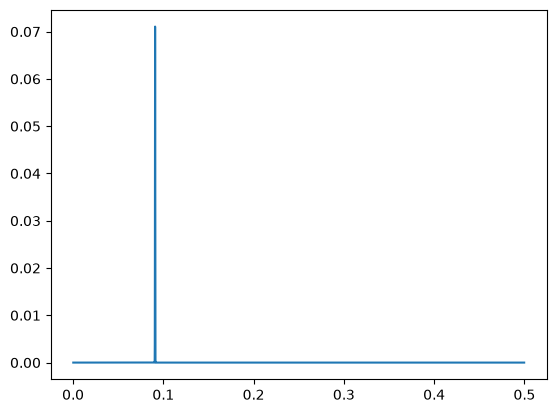

In [264]:
plt.plot(allfvals_modified, postvals)
plt.show()

To better visualize the structure of the posterior, we can zoom near the maximizer. 

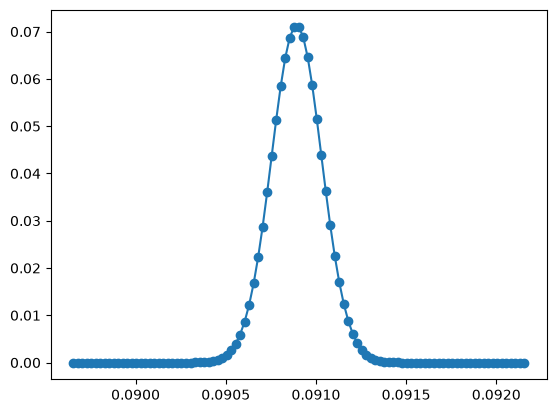

In [265]:
m = 50
est_ind = np.argmax(postvals)

lo = max(est_ind - m, 0)
hi = min(est_ind + m + 1, len(postvals))

plt.plot(allfvals_modified[lo:hi], postvals[lo:hi], marker='o')
plt.show()

Below we find 95\% Bayesian uncertainty interval for $f$. We calculate the posterior probability around the posterior maximizer, and keep expanding the region until the probability is 0.95. 

In [266]:
def PostProbAroundMax(m):
    est_ind = np.argmax(postvals)
    ans = np.sum(postvals[(est_ind-m):(est_ind+m+1)])
    return(ans)

In [267]:
print(PostProbAroundMax(0))
print(PostProbAroundMax(1))
print(PostProbAroundMax(5))
print(PostProbAroundMax(6))


0.07106153136554949
0.21091870883723826
0.6723787250751743
0.7522883959745028


In [268]:
m = 6
est_ind = np.argmax(postvals)
f_est = allfvals_modified[est_ind]
#95% credible interval for f:
ci_f_low = allfvals_modified[est_ind - m]
ci_f_high = allfvals_modified[est_ind + m]
print(np.array([f_est, ci_f_low, ci_f_high])) #this is the 95% uncertainty interval for f

[0.09090455 0.09075454 0.09105455]


To get the interval for the period (which is the inverse of frequency), do the following. 

In [269]:
#For the period (1/frequency)
period_est = 1/f_est
ci_period_low = 1/ci_f_high
ci_period_high = 1/ci_f_low
print(np.array([period_est, ci_period_low, ci_period_high]))

[11.00055006 10.98242724 11.01873278]


This interval is highly concentrated around 11 years. To better interpret the uncertainty interval, we can convert the uncertainty gap into days as follows: 

In [270]:
np.array([(period_est - ci_period_low)*365, (ci_period_high - period_est)*365])

array([6.61482829, 6.63669549])

So the uncertainty period can be summarized as:
\begin{align*}
    [11~\text{years} - 13~\text{days}, 11~\text{years} + 13~\text{days}]
\end{align*}

The reason for such tight concentration is that $RSS(f)$ significantly increases even if $f$ changes slightly from 11. 

In [271]:
print(rss(1/11), rss(1/11.05), rss(1/10.95))

866137.4198804202 887297.8910230198 891246.0938016074


The above clearly shows that the RSS increases significantly even if $f$ moves slightly away from $1/11$. This is the reason why we get such a narrow uncertainty interval for $f$ around $1/11$. 

The assumptions of the model (specifically $\epsilon_t \overset{\text{i.i.d}}{\sim} N(0, \sigma^2)$) also contribute to getting such a narrow interval. Below is a plot of the residuals for this model (with $f$ fixed at the estimated frequency). 

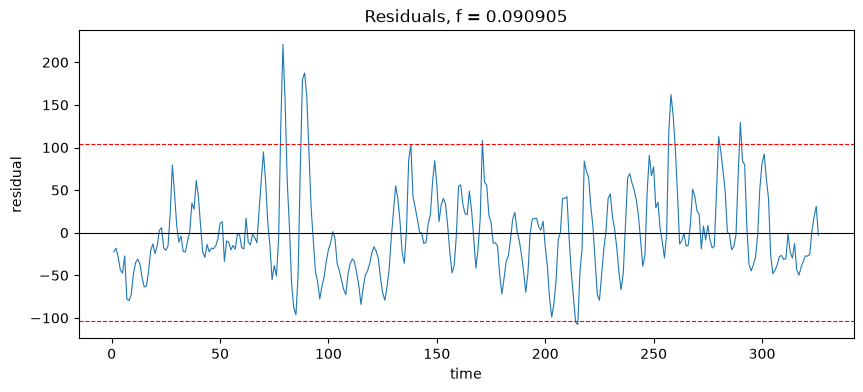

In [272]:
plt.figure(figsize=(10, 4))
plt.plot(x, md.resid, lw=0.8)
plt.axhline(0, color='k', lw=0.8)
plt.axhline(2*sighat, color='r', ls='--', lw=0.8)
plt.axhline(-2*sighat, color='r', ls='--', lw=0.8)
plt.xlabel('time')
plt.ylabel('residual')
plt.title(f'Residuals, f = {f:.6f}')
plt.show()

From the above residual plot, it appears that assuming that the residuals have zero mean is probably not a good assumption. We can try to fit the model: $\beta_0 + \beta_1 \cos(2 \pi f t) + \beta_2 \sin(2 \pi f t) + \epsilon_t$ to the residuals of the previous model. We can see what estimate of $f$ we will be getting. 

In [273]:
def rss(f, y=y):
    x = np.arange(1, n+1)
    xcos = np.cos(2 * np.pi * f * x)
    xsin = np.sin(2 * np.pi * f * x)
    X = np.column_stack([np.ones(n), xcos, xsin])
    md = sm.OLS(y, X).fit()
    rss = np.sum(md.resid ** 2)
    return rss

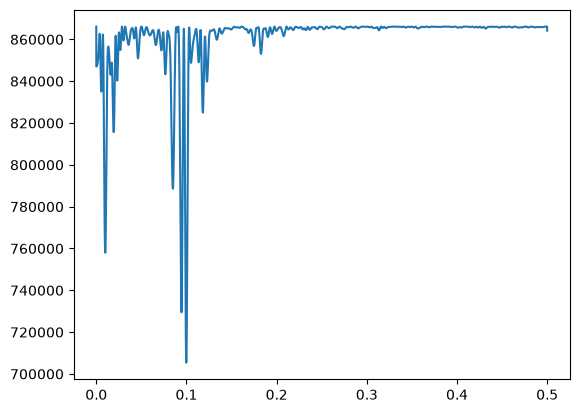

In [274]:
num_f_vals = 10000 #this is the number of different values of f we will try
allfvals = np.linspace(0, 0.5, num_f_vals)
rssvals = np.array([rss(f, md.resid) for f in allfvals])
plt.plot(allfvals, rssvals)
plt.show()

In [275]:
fhat_resid = allfvals[np.argmin(rssvals)]
print(fhat_resid)
print(1/fhat_resid) #this is the estimated periodicity in years

0.09980998099809982
10.019038076152304


The estimate of $f$ is somewhat close to but different from the previous $f$ (which corresponds to 1/11). Overall, the model we have now is: 
\begin{align*}
   y_t = \beta_0 + \beta_{11} \cos(2 \pi f_1 t) + \beta_{12} \sin(2 \pi f_1 t) + \beta_{21} \cos(2 \pi f_2 t) + \beta_{22} \sin(2 \pi f_2 t) + \epsilon_t. 
\end{align*}
We shall revisit such models next week. 

## Efficient Computation of RSS(f) at Fourier Frequencies

Given a time series dataset $y_1, \dots, y_n$, the quantity $RSS(f)$ is defined by
\begin{equation*}
   RSS(f) := \min_{\beta_0, \beta_1, \beta_2} \sum_{t=1}^n \left(y_t - \beta_0 - \beta_1 \cos (2 \pi f t) - \beta_2 \sin(2 \pi f t) \right)^2
\end{equation*}
For each frequency $f$, $RSS(f)$ tells us how well the best sinusoid at frequency $f$ fits the data. This is used for identifying periodicities present in the data. 

Computing $RSS(f)$ for each $f$ in a grid (as above) can be quite time-consuming if the sample size $n$ is large. For example, consider the following audio dataset. The "Hear Piano Note - Middle C.mp3$ is an audio file consisting of about 14 seconds. It contains the sound of the Middle C note in the piano. The python library "Librosa" will be used for loading the audio file (see https://librosa.org/doc/latest/index.html for instructions on installing librosa, and tutorials etc.)

In [305]:
import librosa
y,sr=librosa.load("Hear Piano Note - Middle C.mp3")
sig_noise = 0
y = y + sig_noise*np.random.randn(len(y)) #adding noise to the audio signal
n = len(y)
print(n)
print(sr)
print(n/sr)

301272
22050
13.66312925170068


In [306]:
from IPython.display import Audio, display
display(Audio(y, rate=sr))

This dataset has $n = 301272$ points. Clearly this is a time series dataset of a large size. The data (sound waveform) is plotted below.

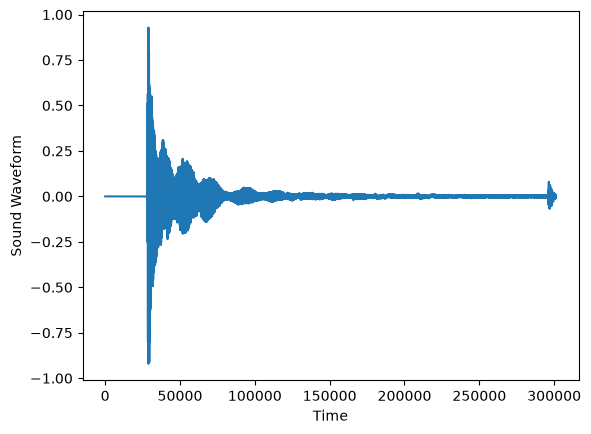

In [307]:
plt.plot(y)
plt.xlabel("Time")
plt.ylabel("Sound Waveform")
plt.show()

The full plot of the data is not very revealing as the data size is very long. But if we restrict to a smaller portion of the dataset, we can visualize the cyclical behavior more easily. 

Text(0, 0.5, 'Sound waveform')

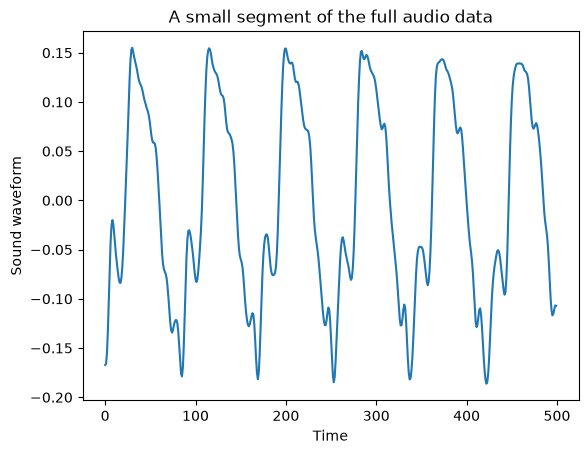

In [308]:
y_smallpart = y[50000:(50000 + 500)]
plt.plot(y_smallpart)
plt.xlabel('Time')
plt.title('A small segment of the full audio data')
plt.ylabel('Sound waveform')

In order to figure out the main frequencies present in the data, we can fit the sinusoidal model to this dataset. As before, we can compute $RSS(f)$ for each $f$ in a grid of frequencies in $[0, 1/2]$, and then find the best $f$ with the smallest $RSS(f)$. However this code will take way too long to run because of the large sample size. 

In [309]:
def rss(f):
    x = np.arange(1, n+1)
    xcos = np.cos(2 * np.pi * f * x)
    xsin = np.sin(2 * np.pi * f * x)
    X = np.column_stack([np.ones(n), xcos, xsin])
    md = sm.OLS(y, X).fit()
    rss = np.sum(md.resid ** 2)
    return rss

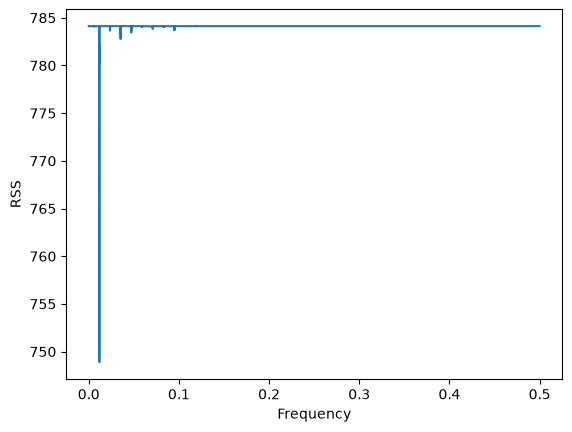

In [310]:
ngrid = 10000
allfvals = np.linspace(0, 0.5, ngrid)
rssvals = np.array([rss(f) for f in allfvals])
plt.plot(allfvals, rssvals)
plt.xlabel('Frequency')
plt.ylabel('RSS')
plt.show()

In [311]:
fhat = allfvals[np.argmin(rssvals)]
print(fhat)

0.011801180118011801


The frequency corresponding to the middle $C$ note on the piano is approximately 261.63 Hz (see e.g., https://en.wikipedia.org/wiki/C_(musical_note)). How does 261.63 Hz relate to the periodogram maximizing frequency (or, equivalently, RSS minimizing frequency) above? The connection between the two is obtained by multiplication by the sampling rate $sr$. The sinusoid $\cos (2 \pi f t)$ completes $f$ cycles in unit time. In this dataset, one unit of time is given by $1/sr$ seconds. So this sinusoid completes $f \times sr$ cycles in one sec which means that, in Hertz (which is the number of cycles per second), the frequency $f$ corresponds to $f \times sr$.  

In [312]:
print(fhat * sr) #this is quite close to 261.63 Hz. 

260.2160216021602


There is a different and much more efficient way of calculating the RSS, using the grid given by Fourier frequencies, and the FFT algorithm. We shall study the details behind this method in the next lecture. 

In [313]:
fft_y = np.fft.fft(y)
m = (n // 2) - 1
fourier_freq = (np.arange(1, m+1))/(n)
pgram_y = (np.abs(fft_y[1:(m+1)]) ** 2)/n
var_y = np.sum((y - np.mean(y)) ** 2)
rss_fft = var_y - 2 * pgram_y

fourier_freq = (np.arange(1, m+1))/(n)
best_freq = fourier_freq[np.argmin(rss_fft)]
print(best_freq)

print(best_freq * sr) #this is quite close to 261.63 Hz. 

0.011799968135107145
260.18929737911253


This method also works if some noise is added to the original audio file. Check thi by going back and changing the sig_noise parameter. For this example, the correct note is recovered even when sig_noise is as high as 1.4 (maybe even slightly larger). You can also verify that the method breaks down when sig_noise is much larger.  